In [1]:
import torch
def cuda_info():
    if torch.cuda.is_available():
        # Target the first GPU
        device_id = 0 

        # Get memory metrics in bytes
        total_mem = torch.cuda.get_device_properties(device_id).total_memory
        reserved_mem = torch.cuda.memory_reserved(device_id)
        allocated_mem = torch.cuda.memory_allocated(device_id)

        # Calculate free space
        free_inside_reserved = reserved_mem - allocated_mem
        total_free_mem = total_mem - allocated_mem

        # Convert bytes to Gigabytes (GB)
        print(f"Total GPU Memory: {total_mem / 1e9:.2f} GB")
        print(f"Allocated Memory: {allocated_mem / 1e9:.2f} GB")
        print(f"Total Available Space: {total_free_mem / 1e9:.2f} GB")
    else:
        print("CUDA is not available on this system.")


In [2]:
import json

def Load_josn(p):
    with open(p, 'r', encoding='utf-8') as f:
        d = json.load(f)
    return d


pdf_urls=Load_josn('data_set\\pdf_urls.json')
question_doc = Load_josn('data_set\\qrels.json')
queries=Load_josn('data_set\\queries.json')
answers=Load_josn('data_set\\answers.json')



In [3]:
import pandas as pd
df = pd.DataFrame.from_dict(question_doc, orient='index')
df.index.name = 'query_id'
df = df.reset_index()  
df.head(2)

,query_id,doc_id,section_id
0,852703f0-8373-43a2-a18a-eb5908ad0779,2410.14077v2,1
1,9199173b-3ed1-4118-88cd-1713fc5fa8a7,2404.00822v2,17


In [4]:
doc_list=df.groupby('doc_id').count().sort_values(by='query_id',ascending=False).head(15).index.tolist()
df=df[df['doc_id'].isin(doc_list)]

### To Download the PDFs use the below block

In [ ]:
import requests, os
from concurrent.futures import ThreadPoolExecutor, as_completed

os.makedirs("pdfs", exist_ok=True)
items ={}
for i ,j in pdf_urls.items():
    if(i in doc_list):
        items[i]=j
    
def download(name_url):
    name, url = name_url
    try:
        fname = os.path.join("pdfs", f"{name}.pdf")
        
        res = requests.get(url, timeout=30)
        res.raise_for_status()
        with open(fname, "wb") as f:
            f.write(res.content)
        return name, True, None
    except Exception as e:
        return name, False, str(e)

pdfs_ = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(download, item) for item in items.items()]
    for future in as_completed(futures):
        name, ok, err = future.result()
        if ok:
            pdfs_.append(name)
        else:
            print(f"failed: {name} -> {err}")

print(f"{len(pdfs_)}/{len(items)} downloaded")

15/15 downloaded


In [5]:
q_df = pd.DataFrame.from_dict(queries, orient='index')  # columns: query, type, source
q_df.index.name = 'query_id'
q_df = q_df.reset_index().rename(columns={'type': 'query_type', 'source': 'query_source', 'query': 'query'})

df = df.merge(q_df, on='query_id', how='left')

In [6]:
answer_df=pd.DataFrame.from_dict(answers,orient="index")
answer_df.index.name='query_id'
df=df.merge(answer_df,on='query_id',how='left')

In [7]:
df=df.rename(columns={0:'answer'})
df.head(2)


,query_id,doc_id,section_id,query,query_type,query_source,answer
0,dc064d11-cd18-4866-8a99-f16b0abec9c6,2401.07294v4,12,How does the MLMM approach affect the analysis...,abstractive,text-image,The MLMM approach affects the analysis of RMSE...
1,7f25612d-9419-4e0a-a89a-9a5a6638e2a6,2411.00816v2,32,Is \(\bar{y}^{\prime}\) considered an unbiased...,extractive,text,"Yes, \(\bar{y}^{\prime}\) is considered an unb..."


In [8]:
df.shape

(150, 7)

---
## Configuration

In [9]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from pydantic import BaseModel
from typing import Literal

# ── Paths ──
PDF_DIR = "pdfs"
TOP_K = 5                      # max chunks retrieved per query (= max k we can evaluate)
K_VALUES = [1, 2, 3, 4, 5]     # k values to compare Precision@k / PassRate@k across

# ── Torch compile fix for Windows (Triton not available) ──
os.environ["TORCHDYNAMO_DISABLE"] = "1"


---
## Pydantic model for LLM judge

In [10]:
class RetrievalJudgement(BaseModel):
    relevant_chunks: list[int]            # which chunk numbers are relevant (1-indexed, ranked by similarity)
    result: Literal["PASS", "FAIL"]       # overall: are ALL retrieved chunks together enough to answer?
    reason: str
    min_chunks_needed: int                # smallest prefix (chunk 1..k, in rank order) that is already
                                           # sufficient on its own to answer the query; -1 if no prefix
                                           # (including the full set) is sufficient


---
## Judge prompts

In [11]:
RETRIEVAL_JUDGE_SYSTEM_PROMPT = (
    "You are an evaluator for a Retrieval-Augmented Generation (RAG) system. "
    "Your task is to determine whether the retrieved chunks contain sufficient "
    "and relevant information to answer the given query correctly.\n\n"
    "You will receive:\n"
    "* A QUERY: the question asked by the user.\n"
    "* A GROUND TRUTH ANSWER: the expected answer.\n"
    "* RETRIEVED CHUNKS: the documents/chunks retrieved by the RAG system, "
    "presented in ranked order (Chunk 1 = most similar to the query as scored "
    "by the retriever, Chunk N = least similar).\n\n"
    "Evaluate the retrieved chunks as a whole.\n\n"
    "Return:\n"
    "PASS if the retrieved chunks contain enough relevant information to "
    "derive the ground-truth answer.\n"
    "FAIL if:\n"
    "* The retrieved chunks are irrelevant to the query.\n"
    "* The chunks do not contain the information required to answer the query.\n"
    "* Important information required for the ground-truth answer is missing.\n"
    "* The chunks contain information that contradicts the ground-truth answer "
    "and would prevent a correct answer.\n"
    "* The information is too vague or incomplete to reasonably derive the expected answer.\n\n"
    "Important rules:\n"
    "* Judge semantic relevance, not just keyword overlap.\n"
    "* Do not use external knowledge.\n"
    "* Do not assume information that is not present in the retrieved chunks.\n"
    "* The ground-truth answer is the reference for determining whether the "
    "retrieved information is sufficient.\n"
    "* The retrieved chunks do not need to contain the exact wording of the "
    "ground-truth answer.\n"
    "* Paraphrases and semantically equivalent information should be considered valid.\n"
    "* Multiple chunks can collectively provide the required information.\n"
    "* Do not judge the quality of the chunking method itself.\n"
    "* Judge only whether the retrieved content is sufficient for answering the query.\n\n"
    "ADDITIONAL TASK - minimum sufficient prefix (this lets us score every k in a single pass):\n"
    "Determine the smallest prefix length k (1 <= k <= N) such that Chunk 1 through "
    "Chunk k ALONE (ignoring any chunks after k) already contain enough information "
    "to answer the query as well as the full set of N chunks does.\n"
    "* If Chunk 1 by itself is already sufficient, min_chunks_needed = 1.\n"
    "* If only the full set of N chunks together is sufficient, min_chunks_needed = N.\n"
    "* If no prefix - including the full set of N chunks - is sufficient, "
    "min_chunks_needed = -1 (this should match a FAIL result).\n"
    "* min_chunks_needed must never exceed N (the total number of chunks shown)."
)

RETRIEVAL_JUDGE_USER_TEMPLATE = (
    "Evaluate the following RAG retrieval result.\n\n"
    "QUERY:\n{query}\n\n"
    "GROUND TRUTH ANSWER:\n{ground_truth_answer}\n\n"
    "RETRIEVED CHUNKS:\n{retrieved_chunks}\n\n"
    "Determine whether the retrieved chunks are sufficient to answer the "
    "query and derive the ground-truth answer.\n\n"
    "Also identify which chunk numbers (1-indexed) contain information "
    "relevant to answering the query. A chunk is relevant if it contributes "
    "ANY part of the ground-truth answer, even partially.\n\n"
    "Finally, report min_chunks_needed: the smallest number of top-ranked "
    "chunks (starting from Chunk 1, in the ranked order shown) that together "
    "are already sufficient to answer the query on their own, or -1 if no "
    "such prefix exists."
)


---
## Helper functions

In [15]:
from rag_eval.embedders import HuggingFaceEmbedder

embedder = HuggingFaceEmbedder()    
def parse_and_chunk(parser, chunker, pdf_path):
    """Parse a PDF and chunk it. Returns list of chunk dicts."""
    doc = parser.parse(pdf_path)
    chunks = chunker.chunk(doc)
    chunk_data = []
    for c in chunks:
        chunk_data.append({
            "chunk_no": c.chunk_no,
            "text": c.text,
            "page_numbers": c.page_numbers,
            "embedding": embedder.embed_query(c.text),
        })
    return chunk_data


def retrieve_top_k(query_embedding, chunks_df, k=TOP_K):
    """Cosine similarity retrieval. Returns top-k chunk dicts, ranked best-first."""
    chunk_embs = np.vstack(chunks_df["embedding"].values)
    query_emb = np.array(query_embedding).reshape(1, -1)
    sims = cosine_similarity(query_emb, chunk_embs)[0]
    top_idx = np.argsort(sims)[-k:][::-1]
    results = []
    for idx in top_idx:
        row = chunks_df.iloc[idx]
        results.append({
            "text": row["text"],
            "page_numbers": row["page_numbers"],
            "similarity": float(sims[idx]),
            "chunk_no": row["chunk_no"],
        })
    return results


def format_chunks_for_judge(retrieved):
    """Format retrieved chunks into a string for the judge prompt."""
    parts = []
    for i, c in enumerate(retrieved, 1):
        pages = c["page_numbers"] if c["page_numbers"] else "?"
        parts.append(f"[Chunk {i}, pages {pages}]\n{c['text']}")
    return "\n\n---\n\n".join(parts)


def run_evaluation_pipeline(parser_name, chunks_df, query_df, judge_llm):
    """Run full retrieval evaluation for one parser pipeline.

    For each query we make exactly ONE LLM judge call, using the full top-TOP_K
    retrieval (chunks ranked 1..TOP_K). That single call returns:
      - relevant_chunks: which ranked chunk numbers are relevant
      - min_chunks_needed: the smallest ranked prefix (1..TOP_K) that is already
        sufficient on its own to answer the query (-1 if none is)

    Both pieces of information let us reconstruct Precision@k and PassRate@k for
    EVERY k in K_VALUES afterwards, with zero extra LLM calls per k.
    """
    results = []

    for idx, row in query_df.iterrows():
        query_text = row["query"]
        gt_answer = row["answer"]
        query_emb = row["query_embedding"]

        # Retrieve once, at the max k we care about (TOP_K)
        retrieved = retrieve_top_k(query_emb, chunks_df, k=TOP_K)

        # Collect retrieved pages
        retrieved_pages = set()
        for c in retrieved:
            pn = c["page_numbers"]
            if pn:
                if isinstance(pn, list):
                    retrieved_pages.update(pn)
                else:
                    retrieved_pages.add(pn)

        # Format for judge
        chunks_str = format_chunks_for_judge(retrieved)

        # LLM Judge call — ONE call per query, covers all k in K_VALUES
        user_prompt = RETRIEVAL_JUDGE_USER_TEMPLATE.format(
            query=query_text,
            ground_truth_answer=gt_answer,
            retrieved_chunks=chunks_str,
        )

        try:
            verdict = judge_llm.invoke_structured(
                prompt=user_prompt,
                response_model=RetrievalJudgement,
                system_prompt=RETRIEVAL_JUDGE_SYSTEM_PROMPT,
            )
            result_val = verdict.result
            reason_val = verdict.reason
            relevant_chunks = verdict.relevant_chunks
            min_chunks_needed = verdict.min_chunks_needed
        except Exception as e:
            result_val = "ERROR"
            reason_val = str(e)
            relevant_chunks = []
            min_chunks_needed = -1

        results.append({
            "query_id": row["query_id"],
            "query": query_text,
            "gt_answer": gt_answer,
            "result": result_val,
            "reason": reason_val,
            "relevant_chunks": relevant_chunks,          # ranked chunk numbers judged relevant
            "num_relevant": len(relevant_chunks),
            "min_chunks_needed": min_chunks_needed,       # ← new: smallest sufficient prefix
            "top_similarity": retrieved[0]["similarity"] if retrieved else 0,
            "retrieved_pages": sorted(retrieved_pages),
            "num_chunks": len(retrieved),
        })

        # Progress indicator
        status = result_val
        print(f"  [{status}] {query_text[:80]}")

    return pd.DataFrame(results)


def compute_metrics_at_k(results_df, k_values=K_VALUES):
    """Compute Precision@k and PassRate@k for every k in k_values, re-using the
    SAME single-call judgements already stored in results_df — no extra LLM calls.

    - Precision@k = avg over queries of (# relevant chunks ranked <= k) / k
    - PassRate@k  = fraction of queries whose min_chunks_needed is defined
                    (!= -1) and <= k, i.e. the query would already PASS using
                    only the top-k retrieved chunks.
    """
    valid = results_df[results_df["result"].isin(["PASS", "FAIL"])]
    total = len(valid)

    metrics = {}
    for k in k_values:
        if total == 0:
            metrics[k] = {"precision@k": 0, "pass_rate": 0, "total": 0}
            continue

        precisions = []
        passes = 0

        for _, row in valid.iterrows():
            relevant_chunks = row["relevant_chunks"] or []
            num_relevant_at_k = sum(1 for c in relevant_chunks if c <= k)
            precisions.append(num_relevant_at_k / k)

            min_needed = row.get("min_chunks_needed", -1)
            if min_needed is not None and min_needed != -1 and min_needed <= k:
                passes += 1

        metrics[k] = {
            "precision@k": round(float(np.mean(precisions)), 4),
            "pass_rate":   round(passes / total, 4),
            "total":       total,
        }

    return metrics


d:\projects\RAG-Chunking-Eval\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7924.81it/s]


In [16]:
cuda_info()

Total GPU Memory: 6.44 GB
Allocated Memory: 0.09 GB
Total Available Space: 6.35 GB


---
## Embed all queries (done once, shared by both pipelines)

In [17]:
df.columns

Index(['query_id', 'doc_id', 'section_id', 'query', 'query_type',
       'query_source', 'answer'],
      dtype='object')

In [18]:
df["query_embedding"] = df["query"].apply(embedder.embed_query)
print(f"Embedded {len(df)} queries")

Embedded 150 queries


---
## Initialize Ollama LLM judge

In [22]:
from rag_eval.llms import OllamaLLM
from rag_eval.llms import GroqLLM
from dotenv import load_dotenv
load_dotenv()

judge_llm = OllamaLLM(model="gemma3:4b", temperature=0.0)
# judge_llm=GroqLLM(model="gpt-oss-120b",api_key=os.getenv("GROQ_KEY"))

# Quick sanity check
test_result = judge_llm.invoke("Say hello in one word.")
print(f"Judge LLM is alive: {test_result}")

Judge LLM is alive: Hello!



---
---
# Pipeline 1: PDFPlumber + RecursiveChunker

### 1a. Parse & chunk

In [23]:
PDF_PATHS=[f"{PDF_DIR}/{i}" for i in os.listdir(PDF_DIR)]

In [24]:
from rag_eval.parsers import PDFPlumberParser
from rag_eval.chunkers import RecursiveChunker

pdfplumber_parser = PDFPlumberParser()
recursive_chunker = RecursiveChunker()
pdfplumber_chunks=[]
for i in PDF_PATHS:
    pdfplumber_chunks=pdfplumber_chunks+parse_and_chunk(pdfplumber_parser,recursive_chunker,i)

pdfplumber_chunks_df = pd.DataFrame(pdfplumber_chunks)

print(f"PDFPlumber chunks: {len(pdfplumber_chunks_df)}")
print(f"Sample: {pdfplumber_chunks_df.iloc[0]['text'][:150]}...")

PDFPlumber chunks: 2874
Sample: Leveraging IS and TC: Optimal order execution subject to
reference strategies
Xue Cheng1, Peng Guo1, and Tai-Ho Wang2
1
LMEQF,DepartmentofFinancialMat...


### 1b. Run retrieval evaluation

In [25]:
print(f"Evaluating {len(df.head(10))} queries against PDFPlumber chunks...\n")

pdfplumber_results = run_evaluation_pipeline(
    parser_name="pdfplumber",
    chunks_df=pdfplumber_chunks_df,
    query_df=df.head(10),
    judge_llm=judge_llm,
)

pdfplumber_results[["query", "result", "reason"]].head(5)

Evaluating 10 queries against PDFPlumber chunks...

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [FAIL] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [PASS] How do implementation shortfall (IS) and target close (TC) orders differ in trad


,query,result,reason
0,How does the MLMM approach affect the analysis...,PASS,"Chunks 1, 3, and 4 collectively provide the in..."
1,Is \(\bar{y}^{\prime}\) considered an unbiased...,PASS,Chunk 1 explicitly states that ar{y}' is an u...
2,Does bounded invariance affect how probability...,PASS,"Chunk 1 contains the relevant information: ""It..."
3,How can graph drawing methods be combined to h...,FAIL,The retrieved chunks are not sufficient to ans...
4,Why might complex moments be relevant despite ...,PASS,"Chunks 1, 2, and 4 collectively provide the ne..."


### 1c. Metrics

In [26]:
pdfplumber_metrics = compute_metrics_at_k(pdfplumber_results, K_VALUES)

pdfplumber_metrics_df = pd.DataFrame(pdfplumber_metrics).T
pdfplumber_metrics_df.index.name = "k"

print("PDFPlumber + RecursiveChunker — Precision@k / PassRate@k:")
pdfplumber_metrics_df


PDFPlumber + RecursiveChunker — Precision@k / PassRate@k:


,precision@k,pass_rate,total
k,,,
1,0.700,0.4,10.0
2,0.700,0.5,10.0
3,0.700,0.8,10.0
4,0.675,0.8,10.0
5,0.620,0.8,10.0


---
---
# Pipeline 2: Docling + RecursiveChunker

### 2a. Parse & chunk

In [27]:
from pathlib import Path
import pandas as pd

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)


def get_or_create_chunks(
    parser,
    chunker,
    pdf_path,
    cache_path,
):
    """Load cached chunks if available; otherwise parse, chunk and cache."""

    if cache_path.exists():
        print(f"Loading cached chunks from: {cache_path}")
        return pd.read_pickle(cache_path)

    print(f"No cached chunks found for: {pdf_path}")
    print("Running parser + chunker...")

    chunks = parse_and_chunk(
        parser,
        chunker,
        pdf_path,
    )

    chunks_df = pd.DataFrame(chunks)
    chunks_df["source_pdf"] = Path(pdf_path).name

    chunks_df.to_pickle(cache_path)

    print(f"Saved chunks to: {cache_path}")

    return chunks_df

In [28]:
from rag_eval.parsers import DoclingParser

docling_parser = DoclingParser(use_gpu=True)

docling_chunks = []

for pdf_path in PDF_PATHS:

    pdf_path = Path(pdf_path)

    cache_path = (
        CACHE_DIR
        / f"{pdf_path.stem}_docling_recursive.pkl"
    )

    chunks_df = get_or_create_chunks(
        parser=docling_parser,
        chunker=recursive_chunker,
        pdf_path=str(pdf_path),
        cache_path=cache_path,
    )

    docling_chunks.append(chunks_df)


docling_chunks_df = pd.concat(
    docling_chunks,
    ignore_index=True,
)

print(f"Total Docling chunks: {len(docling_chunks_df)}")
print(f"Documents: {len(PDF_PATHS)}")
print(f"Sample: {docling_chunks_df.iloc[0]['text'][:150]}...")

Loading cached chunks from: cache\2401.03305v2_docling_recursive.pkl
Loading cached chunks from: cache\2401.06987v2_docling_recursive.pkl
Loading cached chunks from: cache\2401.07294v4_docling_recursive.pkl
Loading cached chunks from: cache\2401.07317v2_docling_recursive.pkl
Loading cached chunks from: cache\2401.11899v3_docling_recursive.pkl
Loading cached chunks from: cache\2401.15478v2_docling_recursive.pkl
Loading cached chunks from: cache\2410.23209v2_docling_recursive.pkl
Loading cached chunks from: cache\2410.23587v3_docling_recursive.pkl
Loading cached chunks from: cache\2410.23841v2_docling_recursive.pkl
Loading cached chunks from: cache\2411.00816v2_docling_recursive.pkl
Loading cached chunks from: cache\2411.03418v4_docling_recursive.pkl
Loading cached chunks from: cache\2411.03676v2_docling_recursive.pkl
Loading cached chunks from: cache\2412.20317v3_docling_recursive.pkl
Loading cached chunks from: cache\2501.00225v2_docling_recursive.pkl
Loading cached chunks from: cache\

### 2b. Run retrieval evaluation

In [29]:
print(f"Evaluating {len(df.head(10))} queries against Docling chunks...\n")

docling_results = run_evaluation_pipeline(
    parser_name="docling",
    chunks_df=docling_chunks_df,
    query_df=df.head(10),
    judge_llm=judge_llm,
)

docling_results[["query", "result", "reason"]].head(5)

Evaluating 10 queries against Docling chunks...

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [PASS] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [PASS] How do implementation shortfall (IS) and target close (TC) orders differ in trad


,query,result,reason
0,How does the MLMM approach affect the analysis...,PASS,"Chunks 1, 3, and 5 collectively provide the ne..."
1,Is \(\bar{y}^{\prime}\) considered an unbiased...,PASS,"Chunks 1, 2, 3, and 4 collectively provide the..."
2,Does bounded invariance affect how probability...,PASS,Chunk 1 directly defines bounded invariance an...
3,How can graph drawing methods be combined to h...,FAIL,The retrieved chunks do not contain the inform...
4,Why might complex moments be relevant despite ...,PASS,Chunks 1 and 2 directly address the relevance ...


### 2c. Metrics

In [31]:
docling_metrics = compute_metrics_at_k(docling_results, K_VALUES)

docling_metrics_df = pd.DataFrame(docling_metrics).T
docling_metrics_df.index.name = "k"

print("Docling + RecursiveChunker — Precision@k / PassRate@k:")
docling_metrics_df


Docling + RecursiveChunker — Precision@k / PassRate@k:


,precision@k,pass_rate,total
k,,,
1,0.800,0.6,10.0
2,0.800,0.7,10.0
3,0.800,0.9,10.0
4,0.725,0.9,10.0
5,0.680,0.9,10.0


---
---
# Side-by-side comparison

In [32]:
comparison = pd.concat(
    {
        "PDFPlumber + Recursive": pdfplumber_metrics_df[["precision@k", "pass_rate"]],
        "Docling + Recursive":    docling_metrics_df[["precision@k", "pass_rate"]],
    },
    axis=1,
)
comparison.index.name = "k"
comparison


PDFPlumber + Recursive           Docling + Recursive          
             precision@k pass_rate         precision@k pass_rate
k                                                               
1                  0.700       0.4               0.800       0.6
2                  0.700       0.5               0.800       0.7
3                  0.700       0.8               0.800       0.9
4                  0.675       0.8               0.725       0.9
5                  0.620       0.8               0.680       0.9

### Per-query diff: where do they disagree?

In [33]:
merged = pdfplumber_results[["query_id", "query", "result", "reason"]].merge(
    docling_results[["query_id", "result", "reason"]],
    on="query_id",
    suffixes=("_pdfplumber", "_docling"),
)

disagree = merged[merged["result_pdfplumber"] != merged["result_docling"]]
print(f"Disagreements: {len(disagree)} / {len(merged)} queries\n")

# Show the interesting cases where parsers diverge
disagree[["query", "result_pdfplumber", "reason_pdfplumber",
          "result_docling", "reason_docling"]]

Disagreements: 1 / 10 queries



,query,result_pdfplumber,reason_pdfplumber,result_docling,reason_docling
6,How does the recursive algorithm ensure that a...,FAIL,The retrieved chunks discuss the 'Hierarchies ...,PASS,"The retrieved chunks, particularly Chunk 2 and..."


### Visual comparison

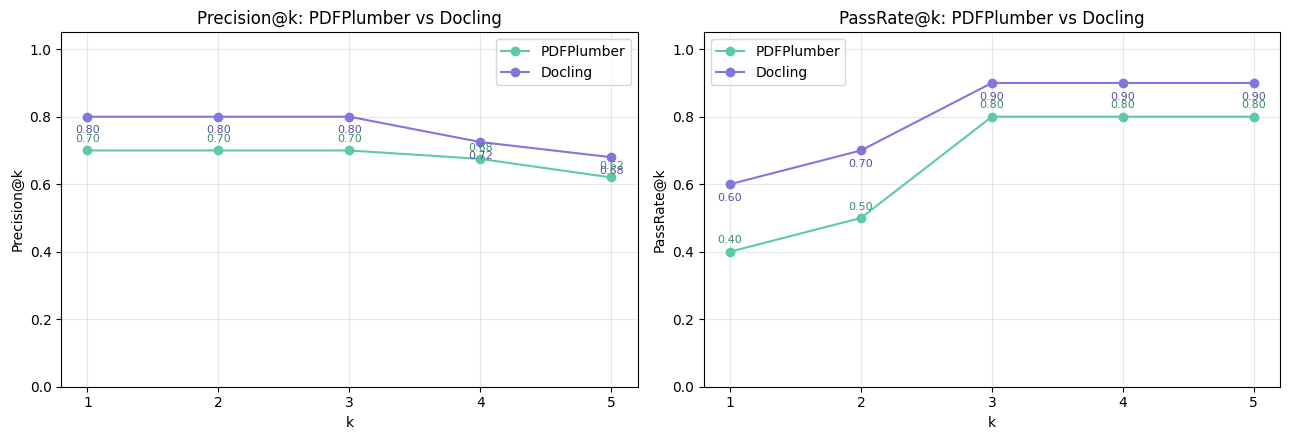

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(
    axes,
    ["precision@k", "pass_rate"],
    ["Precision@k", "PassRate@k"],
):
    ax.plot(K_VALUES, pdfplumber_metrics_df[metric], marker="o",
            label="PDFPlumber", color="#5DCAA5")
    ax.plot(K_VALUES, docling_metrics_df[metric], marker="o",
            label="Docling", color="#7F77DD")

    for k in K_VALUES:
        ax.annotate(f"{pdfplumber_metrics_df.loc[k, metric]:.2f}",
                     xy=(k, pdfplumber_metrics_df.loc[k, metric]),
                     xytext=(0, 6), textcoords="offset points",
                     ha="center", fontsize=8, color="#3d8c6d")
        ax.annotate(f"{docling_metrics_df.loc[k, metric]:.2f}",
                     xy=(k, docling_metrics_df.loc[k, metric]),
                     xytext=(0, -12), textcoords="offset points",
                     ha="center", fontsize=8, color="#5850a0")

    ax.set_title(f"{title}: PDFPlumber vs Docling")
    ax.set_xlabel("k")
    ax.set_ylabel(title)
    ax.set_xticks(K_VALUES)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:

import time
from collections import deque


class RateLimiter:
    """Sliding-window rate limiter: allows at most `max_calls` calls within any
    rolling `period` seconds. Blocks (sleeps) BEFORE a call would exceed the
    limit, so we proactively stay under Groq's 25 req/min cap instead of
    reacting to 429s after the fact."""

    def __init__(self, max_calls=25, period=60):
        self.max_calls = max_calls
        self.period = period
        self.call_times = deque()

    def wait(self):
        now = time.monotonic()
        while self.call_times and now - self.call_times[0] >= self.period:
            self.call_times.popleft()

        if len(self.call_times) >= self.max_calls:
            sleep_time = self.period - (now - self.call_times[0]) + 0.05
            if sleep_time > 0:
                time.sleep(sleep_time)
            now = time.monotonic()
            while self.call_times and now - self.call_times[0] >= self.period:
                self.call_times.popleft()

        self.call_times.append(time.monotonic())


# Shared across BOTH pipelines (pdfplumber + docling) since they hit the same
# Groq account/key — the limit is per-account, not per-pipeline.
rate_limiter = RateLimiter(max_calls=25, period=60)


def call_judge_with_retry(judge_llm, user_prompt, max_retries=5, base_delay=2.0):
    """Call the judge LLM, respecting the rate limiter and retrying with
    exponential backoff if Groq still returns a 429 (e.g. from its
    tokens-per-minute limit, which the request-count limiter above doesn't
    cover)."""
    last_err = None
    for attempt in range(max_retries):
        rate_limiter.wait()
        try:
            return judge_llm.invoke_structured(
                prompt=user_prompt,
                response_model=RetrievalJudgement,
                system_prompt=RETRIEVAL_JUDGE_SYSTEM_PROMPT,
            )
        except Exception as e:
            last_err = e
            msg = str(e).lower()
            is_rate_limit = any(s in msg for s in ("rate limit", "429", "too many requests"))
            if is_rate_limit and attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt)
                print(f"    Rate limited by Groq, retrying in {delay:.1f}s "
                      f"(attempt {attempt + 1}/{max_retries})...")
                time.sleep(delay)
                continue
            raise
    raise last_err

In [36]:
import time
from collections import deque


class RateLimiter:
    """Sliding-window rate limiter: allows at most `max_calls` calls within any
    rolling `period` seconds. Blocks (sleeps) BEFORE a call would exceed the
    limit, so we proactively stay under Groq's 25 req/min cap instead of
    reacting to 429s after the fact."""

    def __init__(self, max_calls=25, period=80):
        self.max_calls = max_calls
        self.period = period
        self.call_times = deque()

    def wait(self):
        now = time.monotonic()
        while self.call_times and now - self.call_times[0] >= self.period:
            self.call_times.popleft()

        if len(self.call_times) >= self.max_calls:
            sleep_time = self.period - (now - self.call_times[0]) + 0.05
            if sleep_time > 0:
                time.sleep(sleep_time)
            now = time.monotonic()
            while self.call_times and now - self.call_times[0] >= self.period:
                self.call_times.popleft()

        self.call_times.append(time.monotonic())


# Shared across BOTH pipelines (pdfplumber + docling) since they hit the same
# Groq account/key — the limit is per-account, not per-pipeline.
rate_limiter = RateLimiter(max_calls=15, period=80)


def call_judge_with_retry(judge_llm, user_prompt, max_retries=5, base_delay=2.0):
    """Call the judge LLM, respecting the rate limiter and retrying with
    exponential backoff if Groq still returns a 429 (e.g. from its
    tokens-per-minute limit, which the request-count limiter above doesn't
    cover)."""
    last_err = None
    for attempt in range(max_retries):
        rate_limiter.wait()
        try:
            return judge_llm.invoke_structured(
                prompt=user_prompt,
                response_model=RetrievalJudgement,
                system_prompt=RETRIEVAL_JUDGE_SYSTEM_PROMPT,
            )
        except Exception as e:
            last_err = e
            msg = str(e).lower()
            is_rate_limit = any(s in msg for s in ("rate limit", "429", "too many requests"))
            if is_rate_limit and attempt < max_retries - 1:
                delay = base_delay * (2 ** attempt)
                print(f"    Rate limited by Groq, retrying in {delay:.1f}s "
                      f"(attempt {attempt + 1}/{max_retries})...")
                time.sleep(delay)
                continue
            raise
    raise last_err

def parse_and_chunk(parser, chunker, pdf_path):
    """Parse a PDF and chunk it. Returns list of chunk dicts."""
    doc = parser.parse(pdf_path)
    chunks = chunker.chunk(doc)
    chunk_data = []
    for c in chunks:
        chunk_data.append({
            "chunk_no": c.chunk_no,
            "text": c.text,
            "page_numbers": c.page_numbers,
            "embedding": embedder.embed_query(c.text),
        })
    return chunk_data


def retrieve_top_k(query_embedding, chunks_df, k=TOP_K):
    """Cosine similarity retrieval. Returns top-k chunk dicts, ranked best-first."""
    chunk_embs = np.vstack(chunks_df["embedding"].values)
    query_emb = np.array(query_embedding).reshape(1, -1)
    sims = cosine_similarity(query_emb, chunk_embs)[0]
    top_idx = np.argsort(sims)[-k:][::-1]
    results = []
    for idx in top_idx:
        row = chunks_df.iloc[idx]
        results.append({
            "text": row["text"],
            "page_numbers": row["page_numbers"],
            "similarity": float(sims[idx]),
            "chunk_no": row["chunk_no"],
        })
    return results


def format_chunks_for_judge(retrieved):
    """Format retrieved chunks into a string for the judge prompt."""
    parts = []
    for i, c in enumerate(retrieved, 1):
        pages = c["page_numbers"] if c["page_numbers"] else "?"
        parts.append(f"[Chunk {i}, pages {pages}]\n{c['text']}")
    return "\n\n---\n\n".join(parts)


def run_evaluation_pipeline(parser_name, chunks_df, query_df, judge_llm):
    """Run full retrieval evaluation for one parser pipeline.

    For each query we make exactly ONE LLM judge call, using the full top-TOP_K
    retrieval (chunks ranked 1..TOP_K). That single call returns:
      - relevant_chunks: which ranked chunk numbers are relevant
      - min_chunks_needed: the smallest ranked prefix (1..TOP_K) that is already
        sufficient on its own to answer the query (-1 if none is)

    Both pieces of information let us reconstruct Precision@k and PassRate@k for
    EVERY k in K_VALUES afterwards, with zero extra LLM calls per k.
    """
    results = []

    for idx, row in query_df.iterrows():
        query_text = row["query"]
        gt_answer = row["answer"]
        query_emb = row["query_embedding"]

        # Retrieve once, at the max k we care about (TOP_K)
        retrieved = retrieve_top_k(query_emb, chunks_df, k=TOP_K)

        # Collect retrieved pages
        retrieved_pages = set()
        for c in retrieved:
            pn = c["page_numbers"]
            if pn:
                if isinstance(pn, list):
                    retrieved_pages.update(pn)
                else:
                    retrieved_pages.add(pn)

        # Format for judge
        chunks_str = format_chunks_for_judge(retrieved)

        # LLM Judge call — ONE call per query, covers all k in K_VALUES
        user_prompt = RETRIEVAL_JUDGE_USER_TEMPLATE.format(
            query=query_text,
            ground_truth_answer=gt_answer,
            retrieved_chunks=chunks_str,
        )

        try:
            verdict = call_judge_with_retry(judge_llm, user_prompt)
            result_val = verdict.result
            reason_val = verdict.reason
            relevant_chunks = verdict.relevant_chunks
            min_chunks_needed = verdict.min_chunks_needed
        except Exception as e:
            result_val = "ERROR"
            reason_val = str(e)
            relevant_chunks = []
            min_chunks_needed = -1

        results.append({
            "query_id": row["query_id"],
            "query": query_text,
            "gt_answer": gt_answer,
            "result": result_val,
            "reason": reason_val,
            "relevant_chunks": relevant_chunks,          # ranked chunk numbers judged relevant
            "num_relevant": len(relevant_chunks),
            "min_chunks_needed": min_chunks_needed,       # ← new: smallest sufficient prefix
            "top_similarity": retrieved[0]["similarity"] if retrieved else 0,
            "retrieved_pages": sorted(retrieved_pages),
            "num_chunks": len(retrieved),
        })

        # Progress indicator
        status = result_val
        print(f"  [{status}] {query_text[:80]}")

    return pd.DataFrame(results)


def compute_metrics_at_k(results_df, k_values=K_VALUES):
    """Compute Precision@k and PassRate@k for every k in k_values, re-using the
    SAME single-call judgements already stored in results_df — no extra LLM calls.

    - Precision@k = avg over queries of (# relevant chunks ranked <= k) / k
    - PassRate@k  = fraction of queries whose min_chunks_needed is defined
                    (!= -1) and <= k, i.e. the query would already PASS using
                    only the top-k retrieved chunks.
    """
    valid = results_df[results_df["result"].isin(["PASS", "FAIL"])]
    total = len(valid)

    metrics = {}
    for k in k_values:
        if total == 0:
            metrics[k] = {"precision@k": 0, "pass_rate": 0, "total": 0}
            continue

        precisions = []
        passes = 0

        for _, row in valid.iterrows():
            relevant_chunks = row["relevant_chunks"] or []
            num_relevant_at_k = sum(1 for c in relevant_chunks if c <= k)
            precisions.append(num_relevant_at_k / k)

            min_needed = row.get("min_chunks_needed", -1)
            if min_needed is not None and min_needed != -1 and min_needed <= k:
                passes += 1

        metrics[k] = {
            "precision@k": round(float(np.mean(precisions)), 4),
            "pass_rate":   round(passes / total, 4),
            "total":       total,
        }

    return metrics


In [37]:
pdfplumber_results = run_evaluation_pipeline(
    parser_name="pdfplumber",
    chunks_df=pdfplumber_chunks_df,
    query_df=df.head(50),
    judge_llm=judge_llm,
)

pdfplumber_results[["query", "result", "reason"]].head(2)
pdfplumber_metrics = compute_metrics_at_k(pdfplumber_results, K_VALUES)

pdfplumber_metrics_df = pd.DataFrame(pdfplumber_metrics).T
pdfplumber_metrics_df.index.name = "k"

print("PDFPlumber + RecursiveChunker — Precision@k / PassRate@k:")
pdfplumber_metrics_df

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [FAIL] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [PASS] How do implementation shortfall (IS) and target close (TC) orders differ in trad
  [PASS] How is spontaneous symmetry breaking characterized for discrete symmetries?
  [PASS] How is the ADO invariant defined for colored knotted graphs?


,precision@k,pass_rate,total
k,,,
1,0.640,0.48,50.0
2,0.660,0.74,50.0
3,0.680,0.88,50.0
4,0.650,0.92,50.0
5,0.648,0.92,50.0


In [38]:
print(f"Evaluating {len(df.head(50))} queries against Docling chunks...\n")

docling_results = run_evaluation_pipeline(
    parser_name="docling",
    chunks_df=docling_chunks_df,
    query_df=df.head(50),
    judge_llm=judge_llm,
)

docling_results[["query", "result", "reason"]].head(2)
docling_metrics = compute_metrics_at_k(docling_results, K_VALUES)

docling_metrics_df = pd.DataFrame(docling_metrics).T
docling_metrics_df.index.name = "k"

print("Docling + RecursiveChunker — Precision@k / PassRate@k:")
docling_metrics_df


Evaluating 50 queries against Docling chunks...

  [PASS] How does the MLMM approach affect the analysis of Root Mean Squared Error (RMSE)
  [PASS] Is \(\bar{y}^{\prime}\) considered an unbiased estimator?
  [PASS] Does bounded invariance affect how probability shares are assigned when preferen
  [FAIL] How can graph drawing methods be combined to handle larger-scale problems?
  [PASS] Why might complex moments be relevant despite not being commonly used in econome
  [PASS] How are complexified tetrahedrons used in knot theory?
  [PASS] How does the recursive algorithm ensure that all agents receive their preferred 
  [PASS] How can we conclude that one estimator is better than another based on Proxy MSE
  [PASS] Does the complex volume of a manifold include both hyperbolic volume and Chern-S
  [PASS] How do implementation shortfall (IS) and target close (TC) orders differ in trad
  [PASS] How is spontaneous symmetry breaking characterized for discrete symmetries?
  [PASS] How is the A

,precision@k,pass_rate,total
k,,,
1,0.820,0.56,50.0
2,0.750,0.80,50.0
3,0.700,0.88,50.0
4,0.665,0.94,50.0
5,0.660,0.94,50.0


In [39]:
comparison = pd.concat(
    {
        "PDFPlumber + Recursive": pdfplumber_metrics_df[["precision@k", "pass_rate"]],
        "Docling + Recursive":    docling_metrics_df[["precision@k", "pass_rate"]],
    },
    axis=1,
)
comparison.index.name = "k"
comparison


PDFPlumber + Recursive           Docling + Recursive          
             precision@k pass_rate         precision@k pass_rate
k                                                               
1                  0.640      0.48               0.820      0.56
2                  0.660      0.74               0.750      0.80
3                  0.680      0.88               0.700      0.88
4                  0.650      0.92               0.665      0.94
5                  0.648      0.92               0.660      0.94

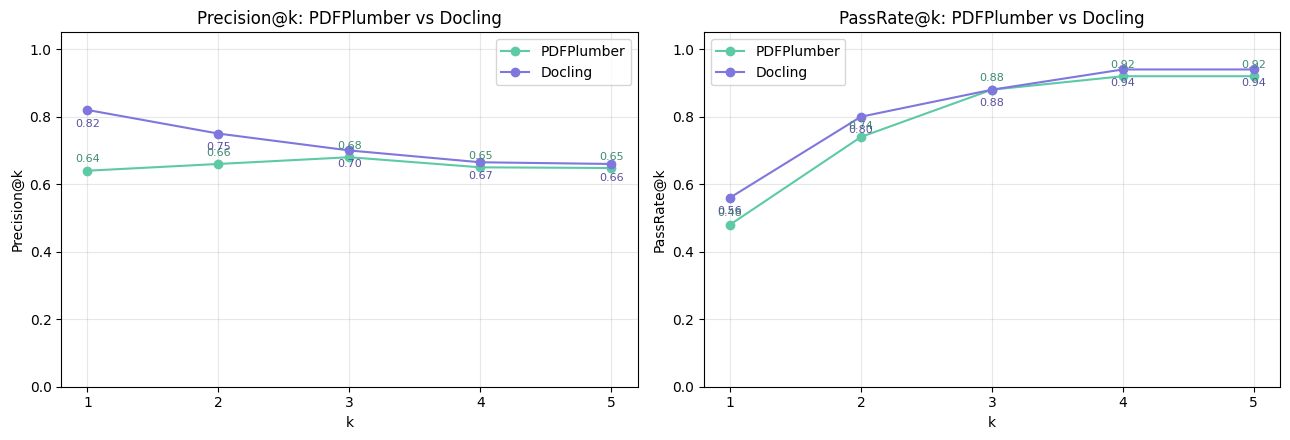

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(
    axes,
    ["precision@k", "pass_rate"],
    ["Precision@k", "PassRate@k"],
):
    ax.plot(K_VALUES, pdfplumber_metrics_df[metric], marker="o",
            label="PDFPlumber", color="#5DCAA5")
    ax.plot(K_VALUES, docling_metrics_df[metric], marker="o",
            label="Docling", color="#7F77DD")

    for k in K_VALUES:
        ax.annotate(f"{pdfplumber_metrics_df.loc[k, metric]:.2f}",
                     xy=(k, pdfplumber_metrics_df.loc[k, metric]),
                     xytext=(0, 6), textcoords="offset points",
                     ha="center", fontsize=8, color="#3d8c6d")
        ax.annotate(f"{docling_metrics_df.loc[k, metric]:.2f}",
                     xy=(k, docling_metrics_df.loc[k, metric]),
                     xytext=(0, -12), textcoords="offset points",
                     ha="center", fontsize=8, color="#5850a0")

    ax.set_title(f"{title}: PDFPlumber vs Docling")
    ax.set_xlabel("k")
    ax.set_ylabel(title)
    ax.set_xticks(K_VALUES)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
